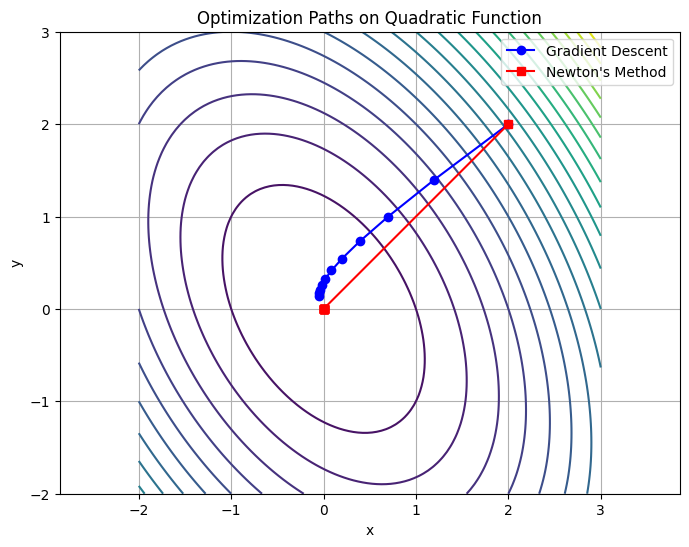

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define a quadratic function f(x) = 0.5 * x^T A x
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])  # Positive definite Hessian

def f(x):
    return 0.5 * x.T @ A @ x

def grad_f(x):
    return A @ x

def hessian_f(x):
    return A  # Constant for quadratic

# Starting point
x_gd = np.array([2.0, 2.0])
x_newton = np.array([2.0, 2.0])

# Store trajectory
gd_path = [x_gd.copy()]
newton_path = [x_newton.copy()]

# Run optimization steps
for _ in range(10):
    # Gradient Descent update
    g = grad_f(x_gd)
    x_gd = x_gd - 0.1 * g
    gd_path.append(x_gd.copy())

    # Newton's Method update
    g = grad_f(x_newton)
    H = hessian_f(x_newton)
    x_newton = x_newton - np.linalg.inv(H) @ g
    newton_path.append(x_newton.copy())

gd_path = np.array(gd_path)
newton_path = np.array(newton_path)

# Plotting the contours and paths
x = np.linspace(-2, 3, 100)
y = np.linspace(-2, 3, 100)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=30, cmap='viridis')
plt.plot(gd_path[:,0], gd_path[:,1], 'o-', label='Gradient Descent', color='blue')
plt.plot(newton_path[:,0], newton_path[:,1], 's-', label="Newton's Method", color='red')
plt.legend()
plt.title('Optimization Paths on Quadratic Function')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.axis('equal')
plt.show()

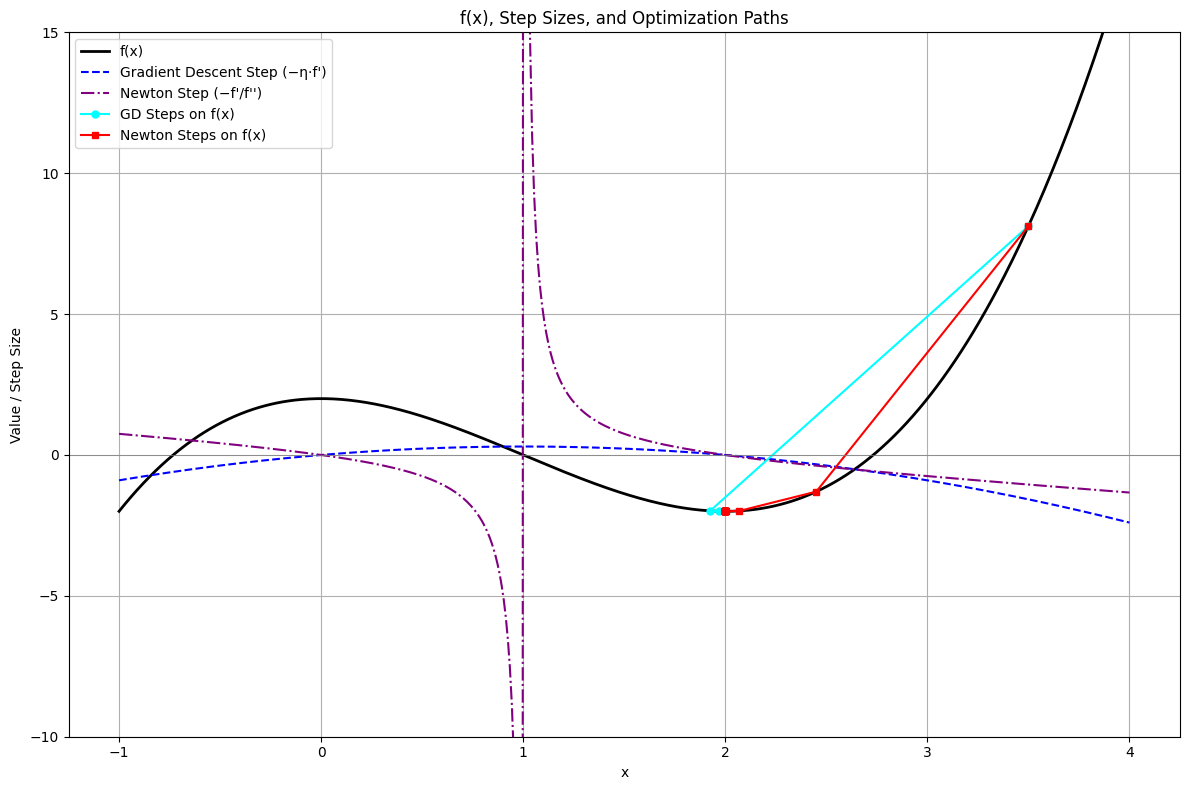

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Function and derivatives
def f(x):
    return x**3 - 3*x**2 + 2

def f_prime(x):
    return 3*x**2 - 6*x

def f_double_prime(x):
    return 6*x - 6

# Step sizes
def gd_step(x, eta=0.1):
    return -eta * f_prime(x)

def newton_step(x, eps=1e-6):
    return -f_prime(x) / (f_double_prime(x) + eps)

# Initial point
x0 = 3.5
lr = 0.1
n_steps = 15

x_gd = x0
x_newton = x0
gd_path = [x_gd]
newton_path = [x_newton]

# Take steps
for _ in range(n_steps):
    x_gd += gd_step(x_gd, lr)
    gd_path.append(x_gd)

    fp = f_prime(x_newton)
    fpp = f_double_prime(x_newton)
    if abs(fpp) > 1e-5:
        x_newton += newton_step(x_newton)
    newton_path.append(x_newton)

gd_path = np.array(gd_path)
newton_path = np.array(newton_path)

# Prepare x range and function evaluations
x = np.linspace(-1, 4, 500)
y = f(x)
gd_steps = gd_step(x, lr)
newton_steps = newton_step(x)

# Plot
plt.figure(figsize=(12, 8))

# f(x)
plt.plot(x, y, label="f(x)", color='black', linewidth=2)

# Step sizes
plt.plot(x, gd_steps, label="Gradient Descent Step (−η·f')", linestyle='--', color='blue')
plt.plot(x, newton_steps, label="Newton Step (−f'/f'')", linestyle='-.', color='purple')

# Optimization paths
plt.plot(gd_path, f(gd_path), 'o-', label="GD Steps on f(x)", color='cyan', markersize=5)
plt.plot(newton_path, f(newton_path), 's-', label="Newton Steps on f(x)", color='red', markersize=5)

# Axis and style
plt.ylim(-10, 15)
plt.axhline(0, color='gray', linewidth=0.5)
plt.title("f(x), Step Sizes, and Optimization Paths")
plt.xlabel("x")
plt.ylabel("Value / Step Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

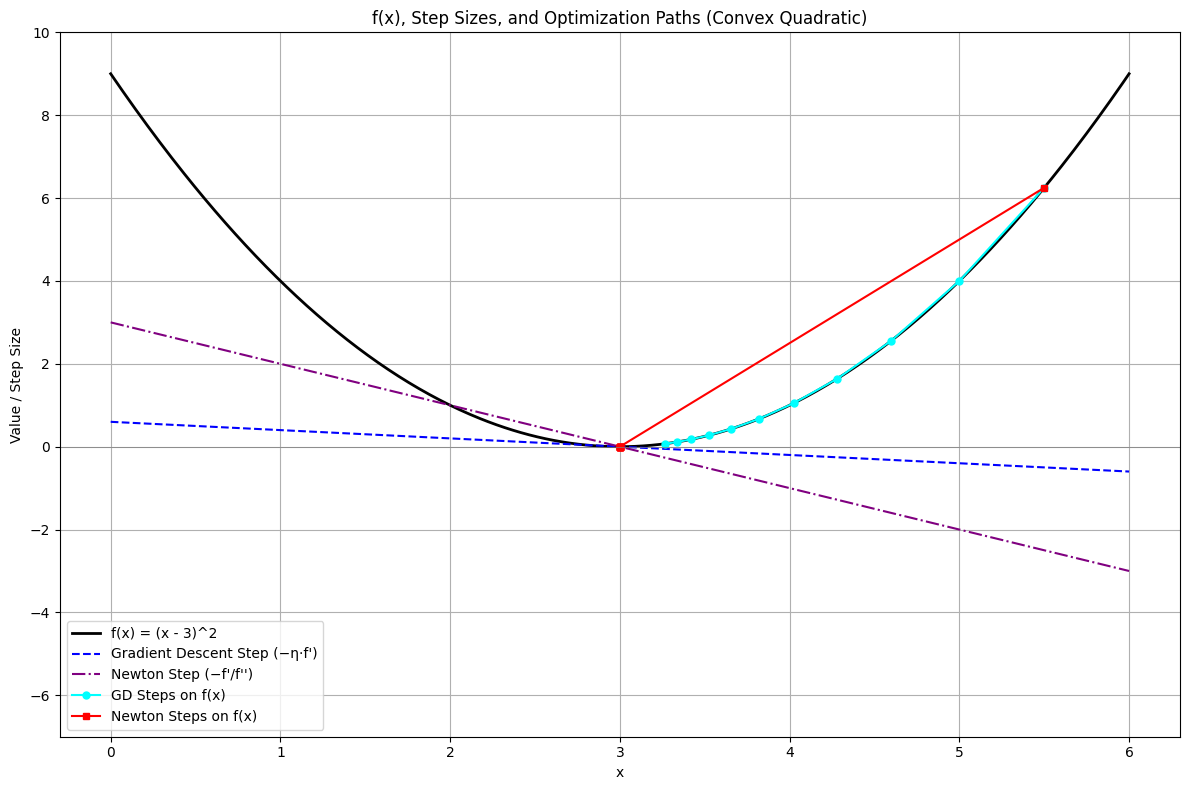

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Function and derivatives
def f(x):
    return (x - 3)**2

def f_prime(x):
    return 2 * (x - 3)

def f_double_prime(x):
    return 2 * np.ones_like(x)  # constant second derivative

# Step sizes
def gd_step(x, eta=0.1):
    return -eta * f_prime(x)

def newton_step(x):
    return -f_prime(x) / f_double_prime(x)

# Initial point
x0 = 5.5
lr = 0.1
n_steps = 10

x_gd = x0
x_newton = x0
gd_path = [x_gd]
newton_path = [x_newton]

# Take steps
for _ in range(n_steps):
    x_gd += gd_step(x_gd, lr)
    gd_path.append(x_gd)

    x_newton += newton_step(x_newton)
    newton_path.append(x_newton)

gd_path = np.array(gd_path)
newton_path = np.array(newton_path)

# Prepare x range and function evaluations
x = np.linspace(0, 6, 500)
y = f(x)
gd_steps = gd_step(x, lr)
newton_steps = newton_step(x)

# Plot
plt.figure(figsize=(12, 8))

# f(x)
plt.plot(x, y, label="f(x) = (x - 3)^2", color='black', linewidth=2)

# Step sizes
plt.plot(x, gd_steps, label="Gradient Descent Step (−η·f')", linestyle='--', color='blue')
plt.plot(x, newton_steps, label="Newton Step (−f'/f'')", linestyle='-.', color='purple')

# Optimization paths
plt.plot(gd_path, f(gd_path), 'o-', label="GD Steps on f(x)", color='cyan', markersize=5)
plt.plot(newton_path, f(newton_path), 's-', label="Newton Steps on f(x)", color='red', markersize=5)

# Axis and style
plt.ylim(-7, 10)
plt.axhline(0, color='gray', linewidth=0.5)
plt.title("f(x), Step Sizes, and Optimization Paths (Convex Quadratic)")
plt.xlabel("x")
plt.ylabel("Value / Step Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

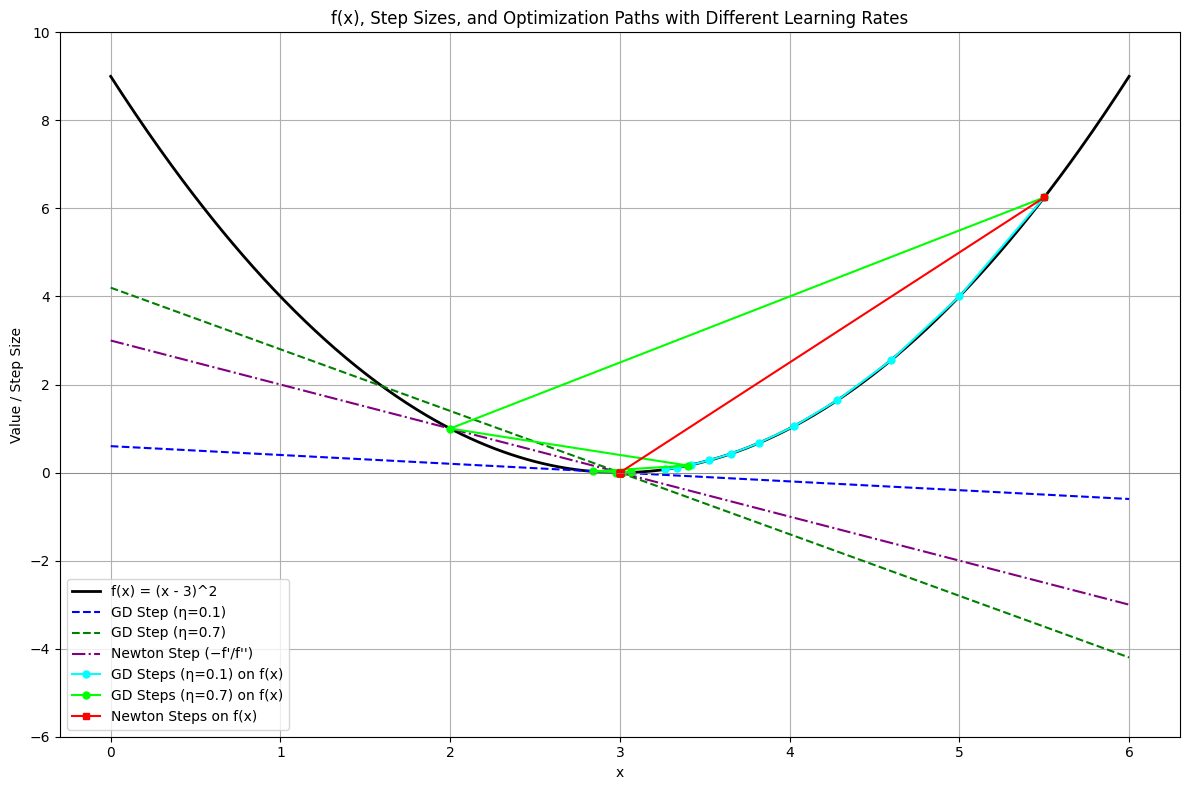

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Function and derivatives
def f(x):
    return (x - 3)**2

def f_prime(x):
    return 2 * (x - 3)

def f_double_prime(x):
    return 2 * np.ones_like(x)  # constant second derivative

# Step sizes
def gd_step(x, eta=0.1):
    return -eta * f_prime(x)

def newton_step(x):
    return -f_prime(x) / f_double_prime(x)

# Initial point
x0 = 5.5
n_steps = 10

# Different learning rates
lr1 = 0.1
lr2 = 0.7

# Initializing paths
x_gd1 = x0
x_gd2 = x0
x_newton = x0
gd_path1 = [x_gd1]
gd_path2 = [x_gd2]
newton_path = [x_newton]

# Take steps with two learning rates for GD
for _ in range(n_steps):
    x_gd1 += gd_step(x_gd1, lr1)
    gd_path1.append(x_gd1)

    x_gd2 += gd_step(x_gd2, lr2)
    gd_path2.append(x_gd2)

    x_newton += newton_step(x_newton)
    newton_path.append(x_newton)

gd_path1 = np.array(gd_path1)
gd_path2 = np.array(gd_path2)
newton_path = np.array(newton_path)

# Prepare x range and function evaluations
x = np.linspace(0, 6, 500)
y = f(x)
gd_steps1 = gd_step(x, lr1)
gd_steps2 = gd_step(x, lr2)
newton_steps = newton_step(x)

# Plot
plt.figure(figsize=(12, 8))

# f(x)
plt.plot(x, y, label="f(x) = (x - 3)^2", color='black', linewidth=2)

# Step sizes for different learning rates
plt.plot(x, gd_steps1, label="GD Step (η=0.1)", linestyle='--', color='blue')
plt.plot(x, gd_steps2, label="GD Step (η=0.7)", linestyle='--', color='green')
plt.plot(x, newton_steps, label="Newton Step (−f'/f'')", linestyle='-.', color='purple')

# Optimization paths
plt.plot(gd_path1, f(gd_path1), 'o-', label="GD Steps (η=0.1) on f(x)", color='cyan', markersize=5)
plt.plot(gd_path2, f(gd_path2), 'o-', label="GD Steps (η=0.7) on f(x)", color='lime', markersize=5)
plt.plot(newton_path, f(newton_path), 's-', label="Newton Steps on f(x)", color='red', markersize=5)

# Axis and style
plt.ylim(-6, 10)
plt.axhline(0, color='gray', linewidth=0.5)
plt.title("f(x), Step Sizes, and Optimization Paths with Different Learning Rates")
plt.xlabel("x")
plt.ylabel("Value / Step Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import plotly.graph_objects as go

# Define the 3D function and its derivatives
def f(x, y):
    return (x - 3)**2 + (y - 3)**2

def grad_f(x, y):
    # Gradient: partial derivatives w.r.t. x and y
    df_dx = 2 * (x - 3)
    df_dy = 2 * (y - 3)
    return np.array([df_dx, df_dy])

def hessian_f(x, y):
    # Hessian: second derivatives w.r.t. x and y
    return np.array([[2, 0], [0, 2]])

# Gradient Descent and Newton's Method step functions
def gd_step(x, y, eta=0.1):
    grad = grad_f(x, y)
    return -eta * grad

def newton_step(x, y):
    grad = grad_f(x, y)
    H_inv = np.linalg.inv(hessian_f(x, y))  # Inverse of the Hessian
    return -H_inv @ grad  # Step in Newton's method

# Initial point and learning rate
x0, y0 = 5.5, 5.5
lr1 = 0.1
lr2 = 0.5
n_steps = 10

# Initialize the paths
gd_path1 = [(x0, y0)]
gd_path2 = [(x0, y0)]
newton_path = [(x0, y0)]

# Perform optimization steps
for _ in range(n_steps):
    # Gradient Descent with different learning rates
    x_gd1, y_gd1 = gd_path1[-1]
    x_gd2, y_gd2 = gd_path2[-1]

    gd_step1 = gd_step(x_gd1, y_gd1, lr1)
    gd_path1.append((x_gd1 + gd_step1[0], y_gd1 + gd_step1[1]))

    gd_step2 = gd_step(x_gd2, y_gd2, lr2)
    gd_path2.append((x_gd2 + gd_step2[0], y_gd2 + gd_step2[1]))

    # Newton's Method
    x_newton, y_newton = newton_path[-1]
    newton_step_val = newton_step(x_newton, y_newton)
    newton_path.append((x_newton + newton_step_val[0], y_newton + newton_step_val[1]))

# Convert paths to numpy arrays
gd_path1 = np.array(gd_path1)
gd_path2 = np.array(gd_path2)
newton_path = np.array(newton_path)



Output hidden; open in https://colab.research.google.com to view.

In [30]:
# Generate the grid for 3D plot
x = np.linspace(0, 10, 500)
y = np.linspace(0, 10, 500)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Create a 3D plot using Plotly
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Viridis', opacity=0.6)])

# Plot the Gradient Descent and Newton's Method paths
fig.add_trace(go.Scatter3d(
    x=gd_path1[:, 0], y=gd_path1[:, 1], z=f(gd_path1[:, 0], gd_path1[:, 1]),
    mode='markers+lines', marker=dict(size=5, color='cyan'), name="GD Steps (η=0.1)"
))

fig.add_trace(go.Scatter3d(
    x=gd_path2[:, 0], y=gd_path2[:, 1], z=f(gd_path2[:, 0], gd_path2[:, 1]),
    mode='markers+lines', marker=dict(size=5, color='lime'), name="GD Steps (η=0.5)"
))

fig.add_trace(go.Scatter3d(
    x=newton_path[:, 0], y=newton_path[:, 1], z=f(newton_path[:, 0], newton_path[:, 1]),
    mode='markers+lines', marker=dict(size=5, color='red'), name="Newton Steps"
))

# Set the labels and title
fig.update_layout(
    title="Gradient Descent and Newton's Method Optimization in 3D",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='f(x, y)',
    ),
    showlegend=True
)

# Show the plot
fig.show()

Output hidden; open in https://colab.research.google.com to view.